# ResNet50 Tiny ImageNet Training

This notebook trains ResNet50 on Tiny ImageNet (200 classes, 64x64 images).

## Dataset:
- **Name**: Tiny ImageNet
- **Classes**: 200 (subset of ImageNet-1K)
- **Image size**: 64x64 pixels
- **Training**: 100,000 images (500 per class)
- **Validation**: 10,000 images (50 per class)
- **Download**: http://cs231n.stanford.edu/tiny-imagenet-200.zip

## Configuration:
- ✅ ResNet50 (25.5M parameters)
- ✅ Adam optimizer (LR: 0.001)
- ✅ OneCycleLR scheduler
- ✅ Dropout: 0.1
- ✅ Batch size: 256
- ✅ Epochs: 20
- ✅ Multi-GPU support

## 1. Environment Setup

In [ ]:
import os
import sys

# Detect environment
IS_KAGGLE = os.path.exists('/kaggle')
IS_COLAB = 'google.colab' in sys.modules

print(f"Kaggle: {IS_KAGGLE} | Colab: {IS_COLAB}")

if IS_KAGGLE:
    TINYIMAGENET_PATH = '/kaggle/input/tiny-imagenet-200'
    WORKING_DIR = '/kaggle/working'
elif IS_COLAB:
    TINYIMAGENET_PATH = '/content/tiny-imagenet-200'
    WORKING_DIR = '/content'
else:
    TINYIMAGENET_PATH = './tiny-imagenet-200'
    WORKING_DIR = '.'

# Add to path
if WORKING_DIR not in sys.path:
    sys.path.insert(0, WORKING_DIR)
if '..' not in sys.path:
    sys.path.insert(0, '..')

print(f"Data path: {TINYIMAGENET_PATH}")
print(f"Working dir: {WORKING_DIR}")

Kaggle: False | Colab: False
Data path: ./data/tiny-imagenet-200
Working dir: .


## 2. Install Packages

In [2]:
%pip install -q albumentations opencv-python-headless
print("✅ Packages installed")

Note: you may need to restart the kernel to use updated packages.
✅ Packages installed


## 3. Download Tiny ImageNet (if needed)

In [3]:
# Download if not available
if not os.path.exists(TINYIMAGENET_PATH):
    print("📥 Downloading Tiny ImageNet...")
    import urllib.request
    import zipfile
    
    url = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
    zip_path = os.path.join(WORKING_DIR, 'tiny-imagenet-200.zip')
    
    urllib.request.urlretrieve(url, zip_path)
    print("  Extracting...")
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(WORKING_DIR)
    
    os.remove(zip_path)
    TINYIMAGENET_PATH = os.path.join(WORKING_DIR, 'tiny-imagenet-200')
    print(f"  ✅ Downloaded to: {TINYIMAGENET_PATH}")
else:
    print(f"✅ Dataset exists: {TINYIMAGENET_PATH}")

📥 Downloading Tiny ImageNet...
  Extracting...
  ✅ Downloaded to: ./tiny-imagenet-200


## 4. Import Libraries

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt

from common.utils import get_device, set_random_seed, plot_training_history, save_training_info
from common.trainer import create_trainer
from assignment9.model import resnet50
from assignment9.data_tinyimagenet import (
    get_tinyimagenet_data_loaders,
    get_tinyimagenet_data_loaders_limited,
    visualize_samples,
    get_tinyimagenet_class_names,
    get_dataset_info
)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Dataset info
info = get_dataset_info()
print(f"\nDataset: {info['name']}")
print(f"Classes: {info['num_classes']}")
print(f"Image size: {info['input_size']}")

PyTorch: 2.8.0
CUDA: False

Dataset: Tiny ImageNet
Classes: 200
Image size: (3, 64, 64)


## 5. Configuration

In [5]:
config = {
    'batch_size': 128,
    'num_workers': 4,
    'lr': 0.001,
    'dropout': 0.1,
    'num_classes': 200,
    'seed': 42,
    'epochs': 50,
    'scheduler': 'onecycle',
    'weight_decay': 1e-4,
    'early_stopping_patience': 5,
    'checkpoint_dir': os.path.join(WORKING_DIR, 'checkpoints'),
}

set_random_seed(config['seed'])
device = get_device()

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

🌱 Random seed set to 42
✅ Using Apple Silicon GPU (Metal Performance Shaders)
Configuration:
  batch_size: 128
  num_workers: 4
  lr: 0.001
  dropout: 0.1
  num_classes: 200
  seed: 42
  epochs: 50
  scheduler: onecycle
  weight_decay: 0.0001
  early_stopping_patience: 5
  checkpoint_dir: ./checkpoints


## 6. Load Data

In [6]:
print("📥 Loading Tiny ImageNet...")

num_gpus = torch.cuda.device_count()
workers = max(4, min(config['num_workers'] * max(1, num_gpus), 16))

# Toggle: 'full' or 'limited'
LOADING_MODE = 'full'

if LOADING_MODE == 'limited':
    train_loader, val_loader = get_tinyimagenet_data_loaders_limited(
        data_dir=TINYIMAGENET_PATH,
        train_samples=20000,
        batch_size=config['batch_size'],
        num_workers=workers,
        augment=True,
        pin_memory=True
    )
else:
    train_loader, val_loader = get_tinyimagenet_data_loaders(
        data_dir=TINYIMAGENET_PATH,
        batch_size=config['batch_size'],
        num_workers=workers,
        augment=True,
        pin_memory=True
    )

print(f"\nTrain: {len(train_loader.dataset):,} samples")
print(f"Val: {len(val_loader.dataset):,} samples")

📥 Loading Tiny ImageNet...

📥 Loading Tiny ImageNet dataset from: ./tiny-imagenet-200
  Batch size: 128
  Workers: 4
  Augmentation: ✅
  Pin memory: ✅

📚 Loading Training Set...


/Users/roul/personal-projects/ERAV4/assignment9/../assignment9/data_tinyimagenet.py:205: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=1.0),
/opt/anaconda3/envs/cifar10/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


  Loaded 100000 samples
  Classes: 200

📚 Loading Validation Set...
  Loaded 10000 samples
  Classes: 200

✅ Data loaders ready!
  Training batches: 781
  Validation batches: 79
  Train samples: ~100,000
  Val samples: ~10,000

Train: 100,000 samples
Val: 10,000 samples


## 7. Visualize Samples

Classes: 200

Training samples:


/opt/anaconda3/envs/cifar10/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


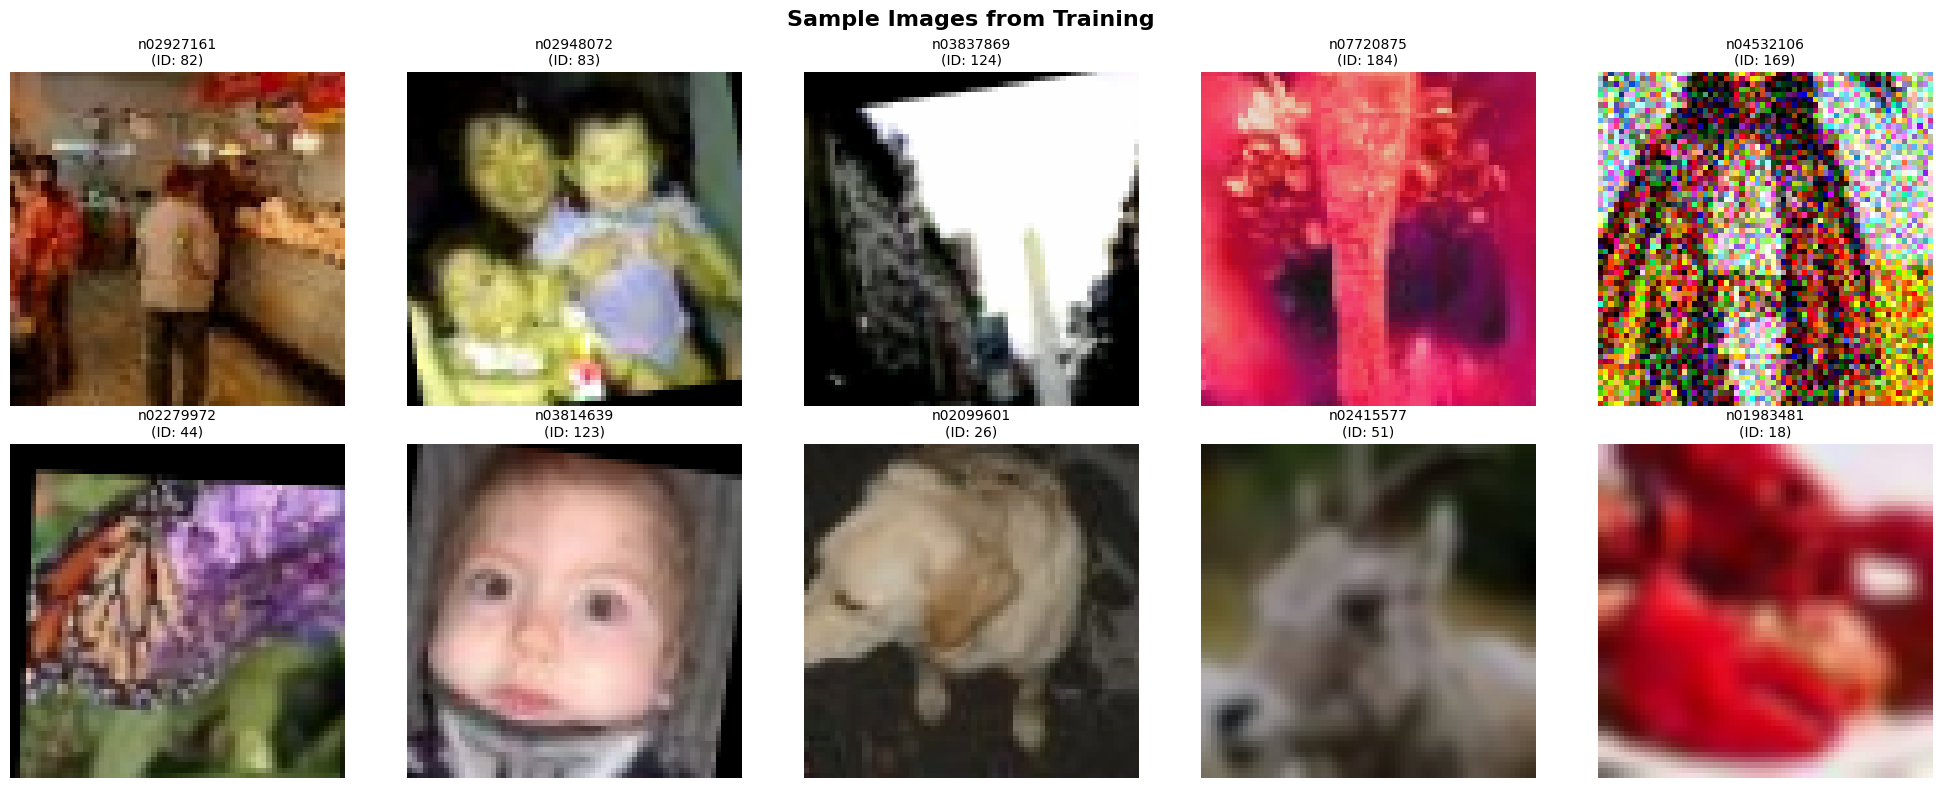

✅ Displayed 10 sample images from Training

Validation samples:


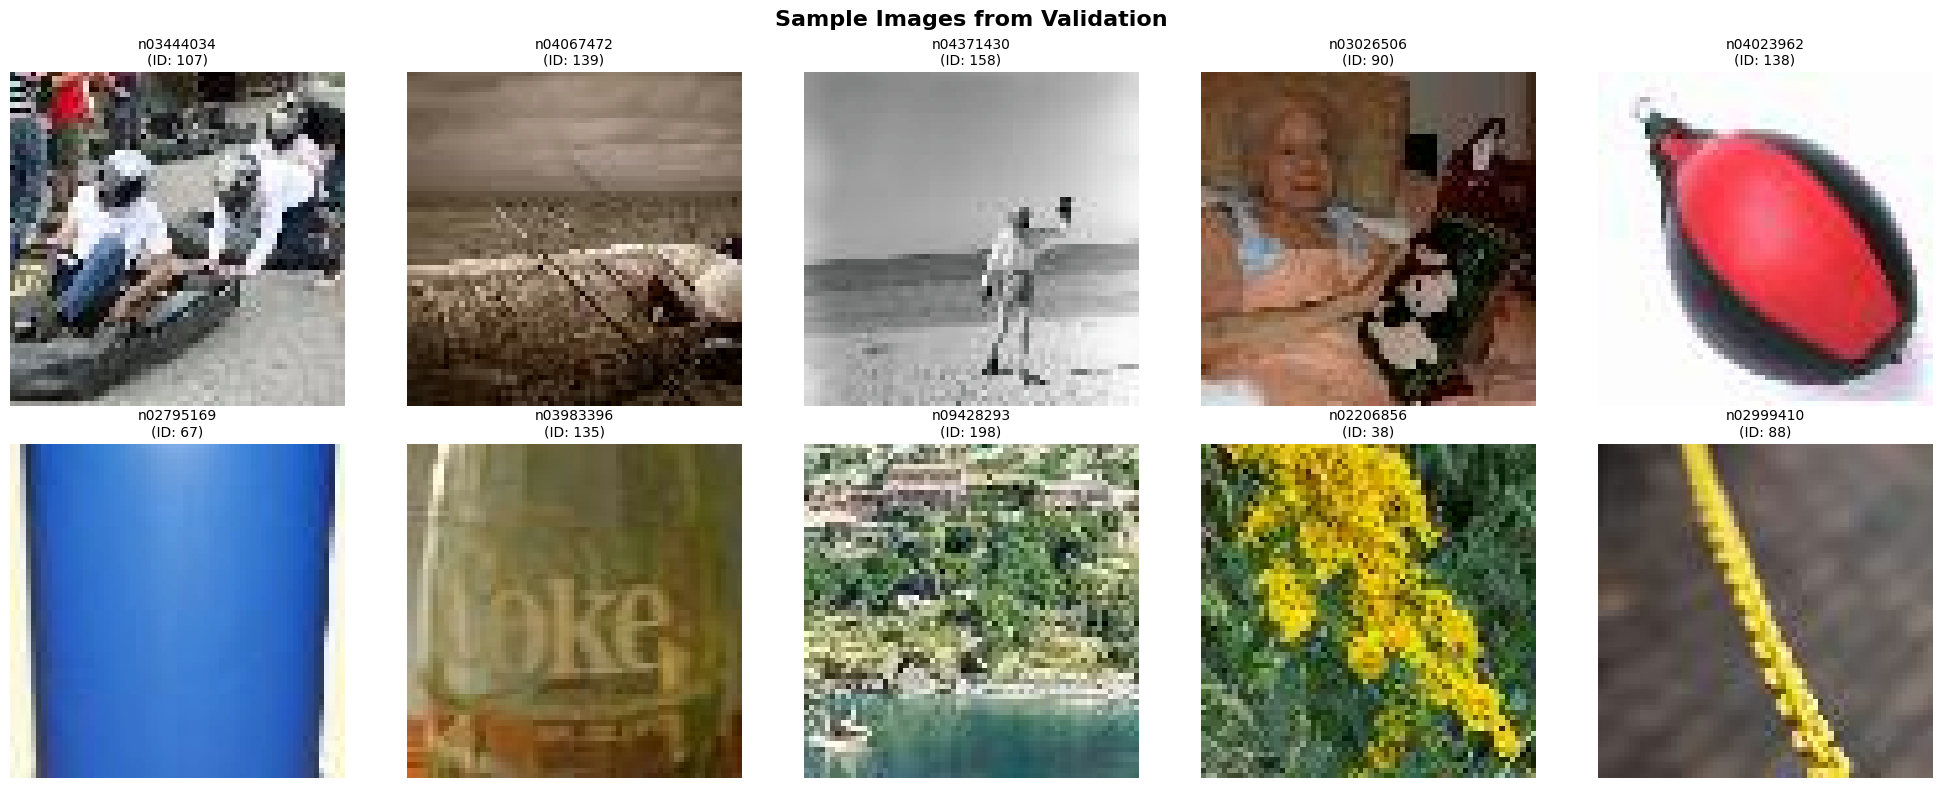

✅ Displayed 10 sample images from Validation


In [7]:
class_names = get_tinyimagenet_class_names(TINYIMAGENET_PATH)
print(f"Classes: {len(class_names)}")

print("\nTraining samples:")
visualize_samples(train_loader, num_samples=10, dataset_name='Training', class_names=class_names)

print("\nValidation samples:")
visualize_samples(val_loader, num_samples=10, dataset_name='Validation', class_names=class_names)

## 8. Create ResNet50 Model

In [8]:
print("🏗️  Creating ResNet50 for Tiny ImageNet...")

num_gpus = torch.cuda.device_count()
print(f"GPUs: {num_gpus}")

model = resnet50(
    num_classes=config['num_classes'],
    dropout=config['dropout'],
    pretrained=False
)

if num_gpus > 1:
    print(f"Using DataParallel with {num_gpus} GPUs")
    model = model.cuda()
    model = nn.DataParallel(model)
    device = torch.device('cuda')
else:
    model = model.to(device)

# Count params
base = model.module if isinstance(model, nn.DataParallel) else model
params = sum(p.numel() for p in base.parameters())
print(f"\nParameters: {params:,}")
print(f"Size: {params * 4 / 1e6:.1f} MB")

🏗️  Creating ResNet50 for Tiny ImageNet...
GPUs: 0

Parameters: 23,917,832
Size: 95.7 MB


## 9. Setup Training (Adam + OneCycleLR)

In [9]:
print("⚙️  Setting up training...")

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=config['lr'],
    weight_decay=config['weight_decay']
)

steps_per_epoch = len(train_loader)
total_steps = config['epochs'] * steps_per_epoch

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config['lr'],
    total_steps=total_steps,
    epochs=config['epochs'],
    steps_per_epoch=steps_per_epoch,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25.0,
    final_div_factor=10000.0
)

print(f"Optimizer: Adam (LR={config['lr']})")
print(f"Scheduler: OneCycleLR")
print(f"  Total steps: {total_steps:,}")
print(f"  Warmup: {int(total_steps * 0.3):,} steps")
print(f"Dropout: {config['dropout']}")
print(f"Weight decay: {config['weight_decay']}")
print("\n✅ Ready to train")

⚙️  Setting up training...
Optimizer: Adam (LR=0.001)
Scheduler: OneCycleLR
  Total steps: 39,050
  Warmup: 11,715 steps
Dropout: 0.1
Weight decay: 0.0001

✅ Ready to train


## 10. Train Model

In [10]:
print("="*70)
print("🚀 Starting Training")
print("="*70)
print(f"Dataset: Tiny ImageNet (200 classes)")
print(f"Epochs: {config['epochs']}")
print(f"Batch size: {config['batch_size']}")
print("="*70 + "\n")

trainer = create_trainer(
    model=model,
    device=device,
    train_loader=train_loader,
    test_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    config=config,
    l2_lambda=0.0
)

print(f"⏰ Started: {time.strftime('%H:%M:%S')}\n")

history = trainer.train(
    num_epochs=config['epochs'],
    early_stopping_patience=config['early_stopping_patience'],
    min_delta=0.001,
    checkpoint_dir=config['checkpoint_dir'],
    scheduler_type='onecycle',
    save_best=True,
    save_latest=True,
    verbose=True
)

print(f"\n⏰ Finished: {time.strftime('%H:%M:%S')}")
print("\n✅ Training complete!")

🚀 Starting Training
Dataset: Tiny ImageNet (200 classes)
Epochs: 50
Batch size: 128

🔧 Model moved to device: mps:0
🔧 L2 regularization disabled (lambda = 0.0)
⏰ Started: 22:24:09

📁 Directory structure created in: ./checkpoints
🚀 Starting training for 50 epochs...
⏰ Training started at: 2025-10-18 22:24:09
📁 Checkpoint directory: ./checkpoints


Epoch  1/50 | Train: 5.3360 (0.61%) | Test: 5.2703 (0.80%) | LR: 0.000040 | Time: 1.9m
  🏆 New best model saved! (Test Acc: 0.80%)


Epoch  2/50 | Train: 5.2324 (1.26%) | Test: 5.0694 (1.82%) | LR: 0.000040 | Time: 2.5m
  🏆 New best model saved! (Test Acc: 1.82%)


Epoch  3/50 | Train: 5.0694 (2.12%) | Test: 4.9179 (3.21%) | LR: 0.000040 | Time: 1.9m
  🏆 New best model saved! (Test Acc: 3.21%)


Epoch  4/50 | Train: 4.9420 (3.13%) | Test: 4.7546 (4.68%) | LR: 0.000040 | Time: 1.9m
  🏆 New best model saved! (Test Acc: 4.68%)


...

Test Evaluation:   0%|          | 0/79 [00:00<?, ?it/s]                             /opt/anaconda3/envs/cifar10/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 8] nodename nor servname provided, or not known>
  data = fetch_version_info()
/opt/anaconda3/envs/cifar10/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 8] nodename nor servname provided, or not known>
  data = fetch_version_info()
/opt/anaconda3/envs/cifar10/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 8] nodename nor servname provided, or not known>
  data = fetch_version_info()
/opt/anaconda3/envs/cifar10/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 8] nodename nor servname provided, or not known>
  

Epoch 32/50 | Train: 3.0668 (29.53%) | Test: 3.1315 (29.45%) | LR: 0.000040 | Time: 3.9m
  🏆 New best model saved! (Test Acc: 29.45%)


Epoch 33:   0%|          | 0/781 [00:00<?, ?it/s]/opt/anaconda3/envs/cifar10/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 8] nodename nor servname provided, or not known>
  data = fetch_version_info()


KeyboardInterrupt: 

Traceback (most recent call last):
  File "/opt/anaconda3/envs/cifar10/lib/python3.12/urllib/request.py", line 1344, in do_open
    h.request(req.get_method(), req.selector, req.data, headers,
  File "/opt/anaconda3/envs/cifar10/lib/python3.12/http/client.py", line 1338, in request
    self._send_request(method, url, body, headers, encode_chunked)
  File "/opt/anaconda3/envs/cifar10/lib/python3.12/http/client.py", line 1384, in _send_request
    self.endheaders(body, encode_chunked=encode_chunked)
  File "/opt/anaconda3/envs/cifar10/lib/python3.12/http/client.py", line 1333, in endheaders
    self._send_output(message_body, encode_chunked=encode_chunked)
  File "/opt/anaconda3/envs/cifar10/lib/python3.12/http/client.py", line 1093, in _send_output
    self.send(msg)
  File "/opt/anaconda3/envs/cifar10/lib/python3.12/http/client.py", line 1037, in send
    self.connect()
  File "/opt/anaconda3/envs/cifar10/lib/python3.12/http/client.py", line 1472, in connect
    super().connect()
  Fil

## 11. Save and Display Results

In [ ]:
# Plot
plot_path = os.path.join(WORKING_DIR, 'training_history_resnet50_tinyimagenet.png')
plot_training_history(history, save_path=plot_path, show_plot=True)
print(f"Plot saved: {plot_path}")

# Save info
info_path = os.path.join(WORKING_DIR, 'resnet50_tinyimagenet_training_info.json')
save_training_info(
    history=history,
    config=config,
    model_name='ResNet50',
    dataset_name='Tiny ImageNet',
    save_path=info_path
)
print(f"Info saved: {info_path}")

# Display results
print("\n" + "="*70)
print("📊 Final Results")
print("="*70)

best_val_acc = max(history['test_accuracy'])
best_epoch = history['test_accuracy'].index(best_val_acc) + 1
best_train_acc = max(history['train_accuracy'])

print(f"\n🏆 Best validation accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
print(f"🏆 Best training accuracy: {best_train_acc:.2f}%")

print(f"\n📈 Final epoch:")
print(f"  Train loss: {history['train_loss'][-1]:.4f}")
print(f"  Train accuracy: {history['train_accuracy'][-1]:.2f}%")
print(f"  Val loss: {history['test_loss'][-1]:.4f}")
print(f"  Val accuracy: {history['test_accuracy'][-1]:.2f}%")

total_time = sum(history['epoch_times'])
print(f"\n⏱️  Total time: {total_time/60:.1f} minutes")
print(f"⏱️  Avg per epoch: {total_time/len(history['epoch_times']):.1f} seconds")

print("\n" + "="*70)
print("✅ All done! 🎉")
print("="*70)